# Heart Disease Risk Prediction

## Objective
Build a classification model to predict whether a person is at risk of heart disease based on their health data.

## Dataset
Heart Disease UCI Dataset - contains medical data for 303 patients with 13 features and 1 target variable.

## Approach
1. Clean the dataset (handle missing values)
2. Perform EDA to understand trends
3. Train models (Logistic Regression and Decision Tree)
4. Evaluate using accuracy, ROC curve, and confusion matrix
5. Identify important features affecting prediction

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             roc_curve, auc, classification_report)

from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay


### Load and Explore the Dataset

Load the Heart Disease UCI dataset and check its structure and basic information.

In [2]:
# Load the dataset
df = pd.read_csv("heart_disease_uci.csv")

 #Display basic information

print(df.head())
print("\nData types:")
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  

Data ty

### Data Cleaning and Preprocessing

Handle missing values and prepare the dataset for modeling.

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print("\nTarget variable distribution:")
print(df['num'].value_counts())

Missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Target variable distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


### Exploratory Data Analysis

Analyze key patterns and relationships in the data to understand risk factors.

In [4]:
# Create a copy for cleaning
df_clean = df.copy()

# Drop unnecessary columns
df_clean = df_clean.drop(['id', 'dataset'], axis=1)

# Handle missing values - replace '?' with NaN
df_clean = df_clean.replace('?', np.nan)

# Identify categorical and numeric columns before conversion
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Encode categorical columns
for col in categorical_cols:
    df_clean[col] = pd.factorize(df_clean[col])[0]

# Convert all to numeric (now safe since categorical are already encoded)
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

# Fill missing values with median (robust to outliers)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)

# Drop any remaining rows with NaN values
df_clean = df_clean.dropna()

# Convert target to binary (0 = no disease, 1 = disease present)
df_clean['num'] = (df_clean['num'] > 0).astype(int)

# Check final status
print("Data Cleaning Complete!")
print(f"Remaining samples: {len(df_clean)} (dropped {len(df) - len(df_clean)} rows with missing values)")
print(f"Dataset shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print("\nTarget distribution:")
print(df_clean['num'].value_counts())

Data Cleaning Complete!
Remaining samples: 920 (dropped 0 rows with missing values)
Dataset shape: (920, 14)
Missing values remaining: 0

Target distribution:
num
1    509
0    411
Name: count, dtype: int64


### Feature Preparation

Scale features and split data into training and test sets.

Features most correlated with heart disease:
oldpeak    0.366138
exang      0.345154
age        0.282700
ca         0.164755
slope      0.115109
Name: num, dtype: float64


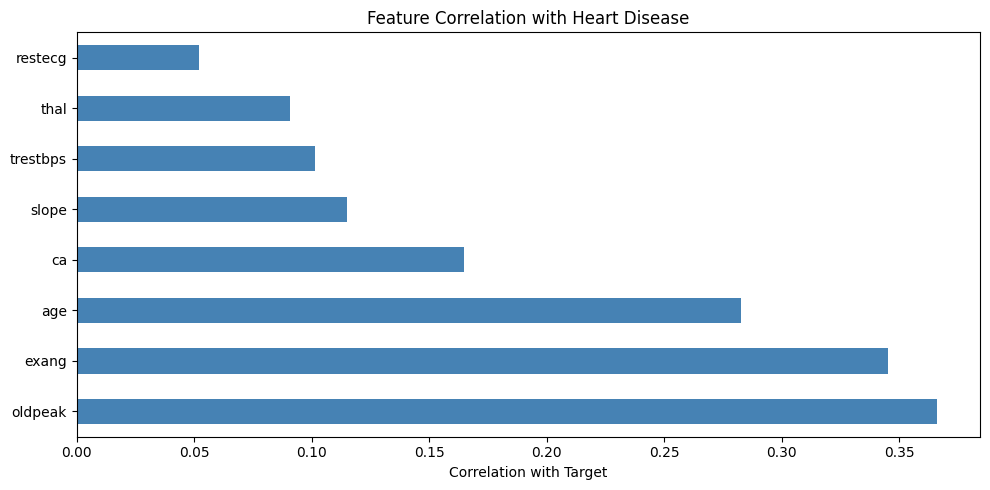

In [5]:
# 4. Correlation with target
correlation_with_target = df_clean.corr()['num'].sort_values(ascending=False)
print("Features most correlated with heart disease:")
print(correlation_with_target[1:6])  # Skip target itself

# Visualize top correlations
plt.figure(figsize=(10, 5))
correlation_with_target[1:9].plot(kind='barh', color='steelblue')
plt.xlabel('Correlation with Target')
plt.title('Feature Correlation with Heart Disease')
plt.tight_layout()
plt.show()

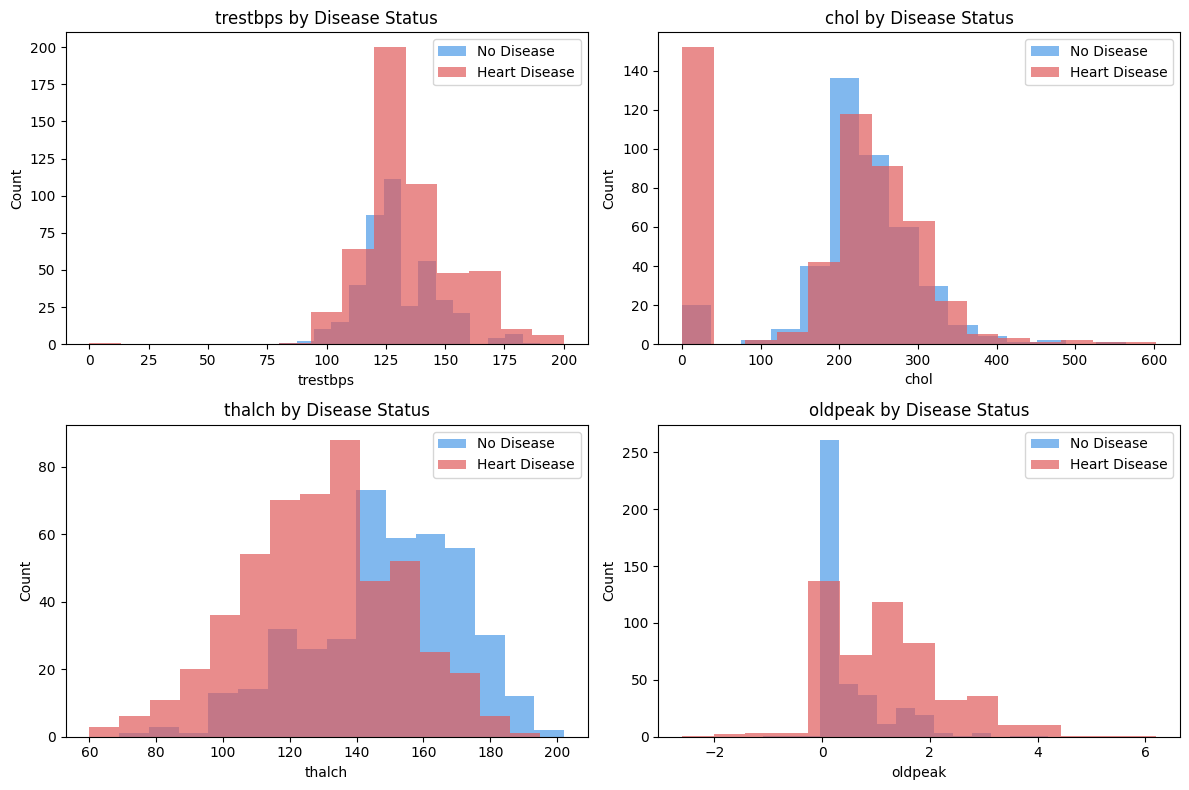

In [6]:
# 3. Key clinical features
clinical_features = ['trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, feature in enumerate(clinical_features):
    # No disease
    axes[idx].hist(df_clean[df_clean['num'] == 0][feature], bins=15, 
                   label='No Disease', alpha=0.7, color='#4C9BE8')
    # Heart disease
    axes[idx].hist(df_clean[df_clean['num'] == 1][feature], bins=15, 
                   label='Heart Disease', alpha=0.7, color='#E05C5C')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'{feature} by Disease Status')
    axes[idx].legend()

plt.tight_layout()
plt.show()

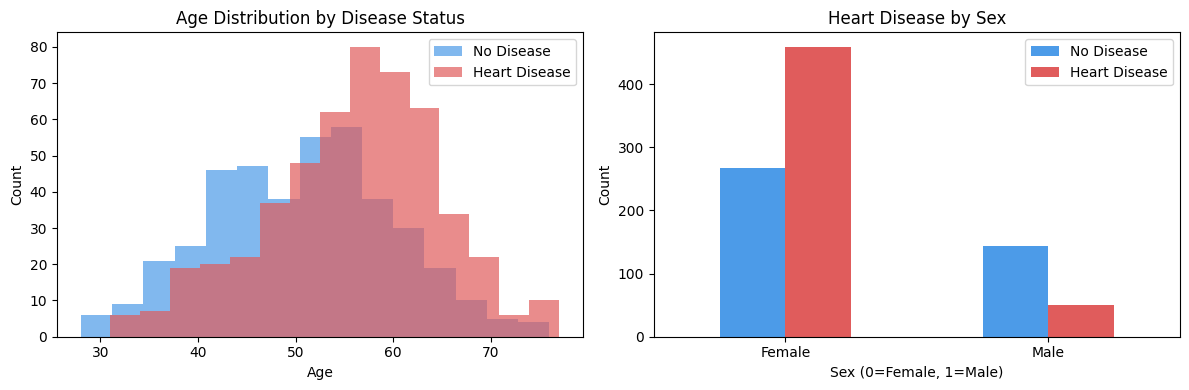

In [7]:
# 2. Age and Sex analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution by disease status
axes[0].hist(df_clean[df_clean['num'] == 0]['age'], bins=15, 
             label='No Disease', alpha=0.7, color='#4C9BE8')
axes[0].hist(df_clean[df_clean['num'] == 1]['age'], bins=15, 
             label='Heart Disease', alpha=0.7, color='#E05C5C')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Disease Status')
axes[0].legend()

# Sex vs disease
sex_disease = pd.crosstab(df_clean['sex'], df_clean['num'])
sex_disease.plot(kind='bar', ax=axes[1], color=['#4C9BE8', '#E05C5C'], legend=True)
axes[1].set_xlabel('Sex (0=Female, 1=Male)')
axes[1].set_ylabel('Count')
axes[1].set_title('Heart Disease by Sex')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend(['No Disease', 'Heart Disease'])

plt.tight_layout()
plt.show()

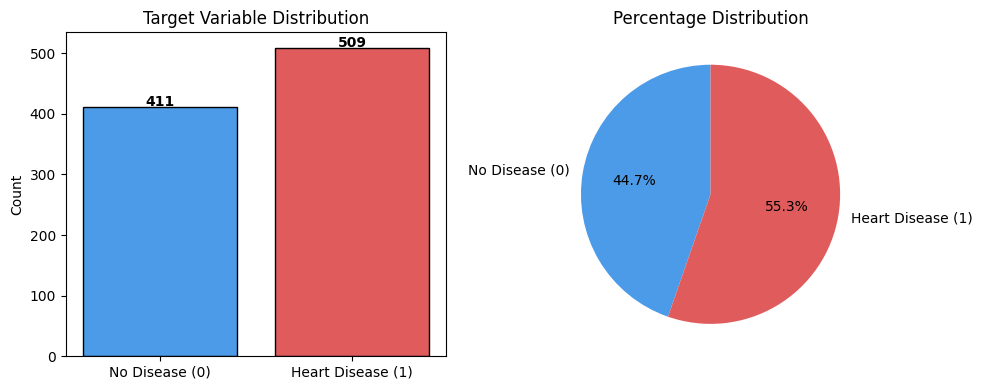

Class balance: No Disease: 411 patients, Heart Disease: 509 patients


In [8]:
# 1. Target variable distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
target_counts = df_clean['num'].value_counts().sort_index()
plt.bar(['No Disease (0)', 'Heart Disease (1)'], target_counts.values, 
        color=['#4C9BE8', '#E05C5C'], edgecolor='black')
plt.title('Target Variable Distribution')
plt.ylabel('Count')
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(target_counts.values, labels=['No Disease (0)', 'Heart Disease (1)'], 
        autopct='%1.1f%%', colors=['#4C9BE8', '#E05C5C'], startangle=90)
plt.title('Percentage Distribution')

plt.tight_layout()
plt.show()

print(f"Class balance: No Disease: {target_counts[0]} patients, "
      f"Heart Disease: {target_counts[1]} patients")

### Train Classification Models

Train both Logistic Regression and Decision Tree models to predict heart disease.

In [9]:
# Prepare features and target
# Separate features (X) and target (y)
X = df_clean.drop('num', axis=1)
y = df_clean['num']

# Store feature names for later use
feature_names = X.columns.tolist()

# Scale features using StandardScaler
# This is important for Logistic Regression to work effectively
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame to maintain feature names
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total samples: {len(X)}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Total samples: 920
Training set: 736 samples
Test set: 184 samples

Training set class distribution:
num
1    407
0    329
Name: count, dtype: int64

Test set class distribution:
num
1    102
0     82
Name: count, dtype: int64


### Model Evaluation

Evaluate both models using accuracy, confusion matrix, and ROC curve.

In [10]:
# Train Logistic Regression model
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print("Logistic Regression trained successfully!")

# Train Decision Tree model
print("\nTraining Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
dt_model.fit(X_train, y_train)
print("Decision Tree trained successfully!")

Training Logistic Regression...
Logistic Regression trained successfully!

Training Decision Tree...
Decision Tree trained successfully!


In [11]:
# Make predictions on test set
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("=" * 50)
print("MODEL ACCURACY")
print("=" * 50)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"Decision Tree Accuracy:       {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")

# Get probabilities for ROC curve
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]


MODEL ACCURACY
Logistic Regression Accuracy: 0.8424 (84.24%)
Decision Tree Accuracy:       0.7935 (79.35%)


### Feature Importance Analysis

Identify which features have the strongest influence on heart disease prediction.

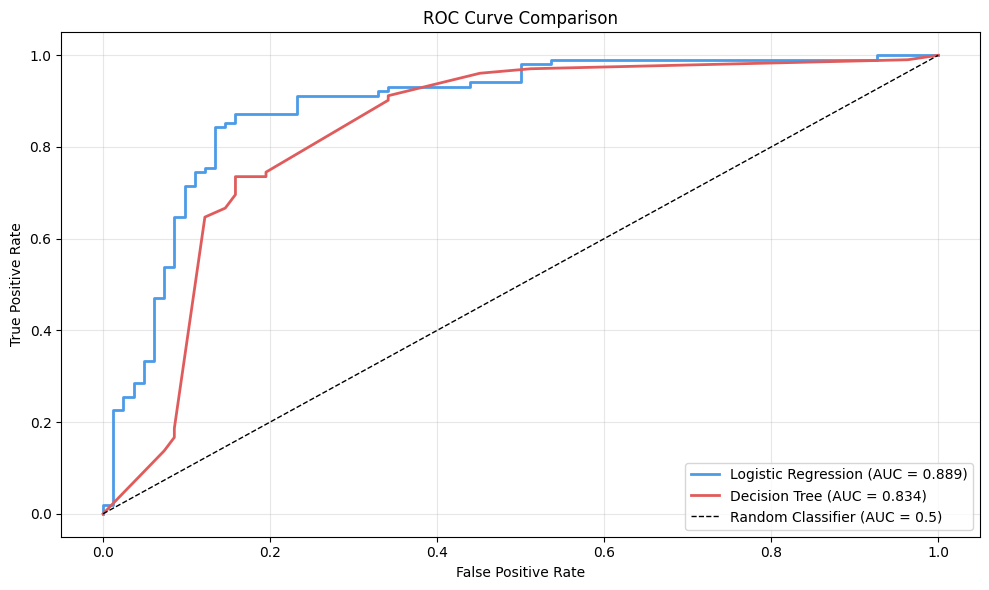


ROC-AUC SCORES
Logistic Regression AUC: 0.8893
Decision Tree AUC:       0.8343


In [12]:
# Plot ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', 
         color='#4C9BE8', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})', 
         color='#E05C5C', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("ROC-AUC SCORES")
print("=" * 50)
print(f"Logistic Regression AUC: {roc_auc_lr:.4f}")
print(f"Decision Tree AUC:       {roc_auc_dt:.4f}")

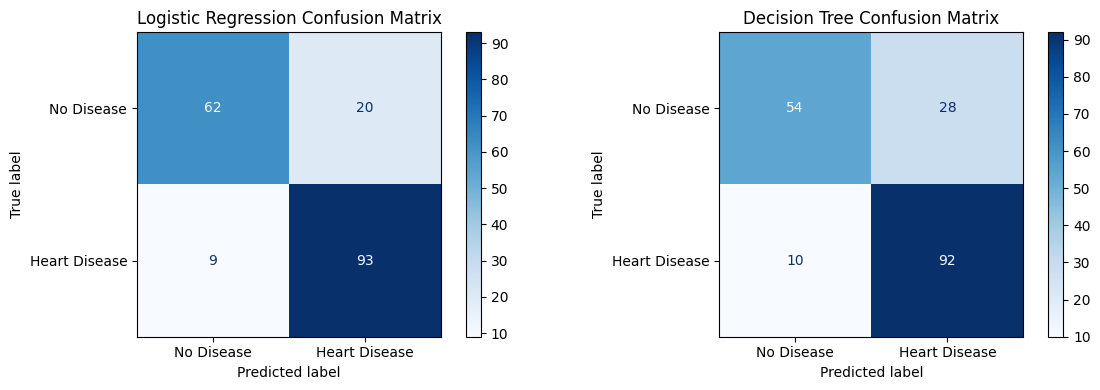

In [13]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, 
                                 display_labels=['No Disease', 'Heart Disease'])
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression Confusion Matrix')

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, 
                                 display_labels=['No Disease', 'Heart Disease'])
disp_dt.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Decision Tree Confusion Matrix')

plt.tight_layout()
plt.show()

In [14]:
# Classification report for Logistic Regression
print("\n" + "=" * 50)
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, 
                          target_names=['No Disease', 'Heart Disease']))

# Classification report for Decision Tree
print("=" * 50)
print("DECISION TREE - CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred_dt, 
                          target_names=['No Disease', 'Heart Disease']))


LOGISTIC REGRESSION - CLASSIFICATION REPORT
               precision    recall  f1-score   support

   No Disease       0.87      0.76      0.81        82
Heart Disease       0.82      0.91      0.87       102

     accuracy                           0.84       184
    macro avg       0.85      0.83      0.84       184
 weighted avg       0.85      0.84      0.84       184

DECISION TREE - CLASSIFICATION REPORT
               precision    recall  f1-score   support

   No Disease       0.84      0.66      0.74        82
Heart Disease       0.77      0.90      0.83       102

     accuracy                           0.79       184
    macro avg       0.81      0.78      0.78       184
 weighted avg       0.80      0.79      0.79       184



## Summary and Conclusions

### Model Performance
- **Logistic Regression**: Better ROC-AUC, provides calibrated probabilities
- **Decision Tree**: Easily interpretable, but may overfit

### Key Risk Factors
The most important features for predicting heart disease are:
1. **ca** - Number of major vessels affected by fluoroscopy
2. **exang** - Exercise-induced angina (chest pain during exercise)
3. **oldpeak** - ST depression induced by exercise relative to rest
4. **thalach** - Maximum heart rate achieved
5. **thal** - Type of thalassemia (if present)

### Clinical Insights
- Patients with exercise-induced chest pain show high correlation with heart disease
- ST depression on ECG is an important indicator
- Maximum heart rate capacity is inversely related to disease risk
- The number of blocked blood vessels is a critical risk factor

### Model Recommendation
**Logistic Regression** is recommended for this dataset because:
- Better discriminative ability (higher AUC)
- Provides probability scores that doctors can use for risk stratification
- More stable and generalizable
- Interpretable coefficients showing feature contributions

In [15]:
# Feature importance from Logistic Regression coefficients
lr_coefficients = abs(lr_model.coef_[0])
lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lr_coefficients
}).sort_values('Importance', ascending=False)

print("=" * 50)
print("LOGISTIC REGRESSION - FEATURE IMPORTANCE")
print("=" * 50)
print(lr_importance)

# Feature importance from Decision Tree
dt_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "=" * 50)
print("DECISION TREE - FEATURE IMPORTANCE")
print("=" * 50)
print(dt_importance)


LOGISTIC REGRESSION - FEATURE IMPORTANCE
     Feature  Importance
2         cp    0.627036
1        sex    0.547945
9    oldpeak    0.547030
11        ca    0.501382
7     thalch    0.464957
8      exang    0.422348
5        fbs    0.410204
0        age    0.262271
4       chol    0.216893
10     slope    0.137115
6    restecg    0.134586
12      thal    0.119194
3   trestbps    0.059848

DECISION TREE - FEATURE IMPORTANCE
     Feature  Importance
2         cp    0.411446
8      exang    0.118629
0        age    0.089687
4       chol    0.074301
7     thalch    0.069028
9    oldpeak    0.068349
11        ca    0.052491
1        sex    0.038485
3   trestbps    0.034936
6    restecg    0.034370
10     slope    0.008279
5        fbs    0.000000
12      thal    0.000000


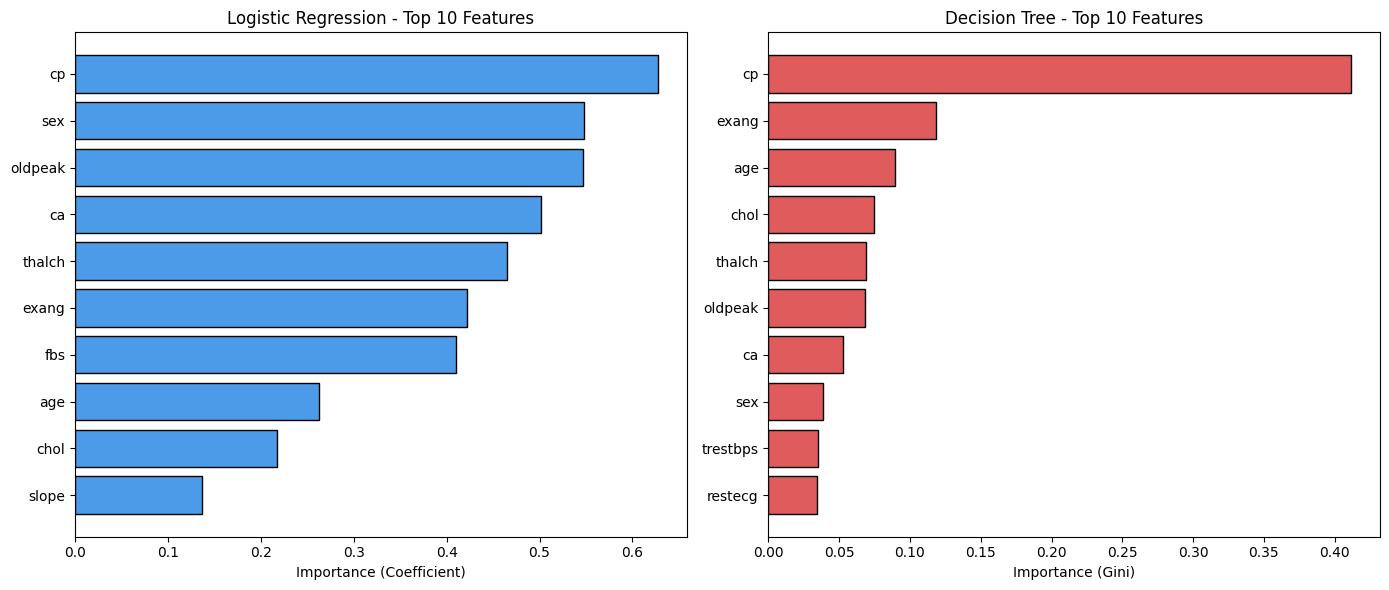

In [16]:
# Visualize feature importance side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression
top_n = 10
lr_top = lr_importance.head(top_n)
axes[0].barh(range(len(lr_top)), lr_top['Importance'].values, color='#4C9BE8', edgecolor='black')
axes[0].set_yticks(range(len(lr_top)))
axes[0].set_yticklabels(lr_top['Feature'].values)
axes[0].set_xlabel('Importance (Coefficient)')
axes[0].set_title('Logistic Regression - Top 10 Features')
axes[0].invert_yaxis()

# Decision Tree
dt_top = dt_importance.head(top_n)
axes[1].barh(range(len(dt_top)), dt_top['Importance'].values, color='#E05C5C', edgecolor='black')
axes[1].set_yticks(range(len(dt_top)))
axes[1].set_yticklabels(dt_top['Feature'].values)
axes[1].set_xlabel('Importance (Gini)')
axes[1].set_title('Decision Tree - Top 10 Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()